In [32]:
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

from IPython.display import clear_output
import matplotlib.colors as mcolors
from scipy.ndimage import label
from skimage.segmentation import watershed
from torchvision.utils import make_grid

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parte 0

In [33]:
from Ellipses import *
from plottings import *

ellipses_sim = EllipsesSimulator(128, 5, 10)
frames, ground_truth = ellipses_sim.simulate(30)
frames_with_bboxes = visualize_ground_truth(frames, ground_truth)

In [59]:
parts = np.array([list(map(float, x.split(','))) for x in ground_truth])
parts[:,0]-1

array([ 0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,
        2.,  2.,  3.,  3.,  3.,  3.,  3.,  4.,  4.,  4.,  4.,  4.,  5.,
        5.,  5.,  5.,  5.,  6.,  6.,  6.,  6.,  6.,  7.,  7.,  7.,  7.,
        7.,  8.,  8.,  8.,  8.,  8.,  9.,  9.,  9.,  9.,  9., 10., 10.,
       10., 10., 10., 11., 11., 11., 11., 11., 12., 12., 12., 12., 12.,
       13., 13., 13., 13., 13., 14., 14., 14., 14., 14., 15., 15., 15.,
       15., 15., 16., 16., 16., 16., 16., 17., 17., 17., 17., 17., 18.,
       18., 18., 18., 18., 19., 19., 19., 19., 19., 20., 20., 20., 20.,
       20., 21., 21., 21., 21., 21., 22., 22., 22., 22., 22., 23., 23.,
       23., 23., 23., 24., 24., 24., 24., 24., 25., 25., 25., 25., 25.,
       26., 26., 26., 26., 26., 27., 27., 27., 27., 27., 28., 28., 28.,
       28., 28., 29., 29., 29., 29., 29.])

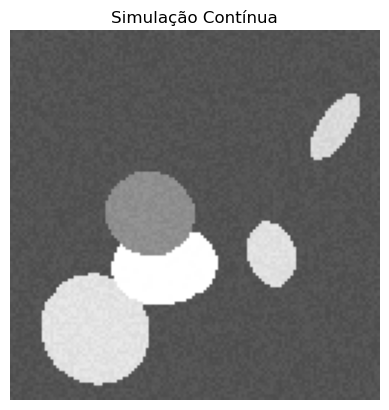

In [34]:
plot_simulation_frames(frames)

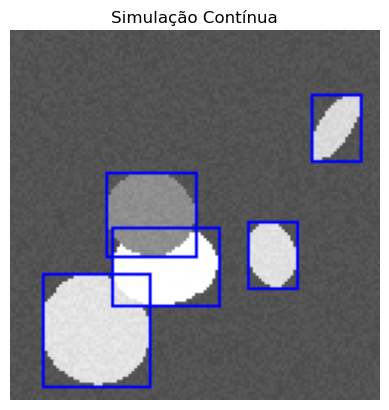

In [39]:
plot_simulation_frames(frames_with_bboxes)

In [37]:
frames_with_noisy_bboxes, noisy_annotations = create_noisy_bboxes(frames, ground_truth, 0.1)

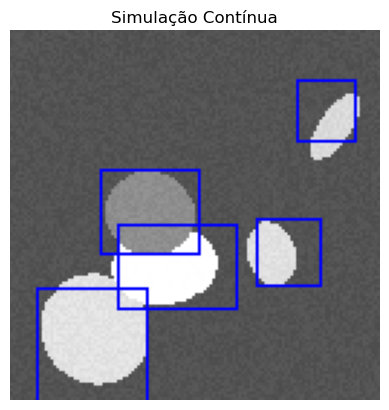

In [40]:
plot_simulation_frames(frames_with_noisy_bboxes)